# 고급 시각화

In [8]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print('환경 설정 완료!')

환경 설정 완료!


tips 데이터 앞 3행:
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3


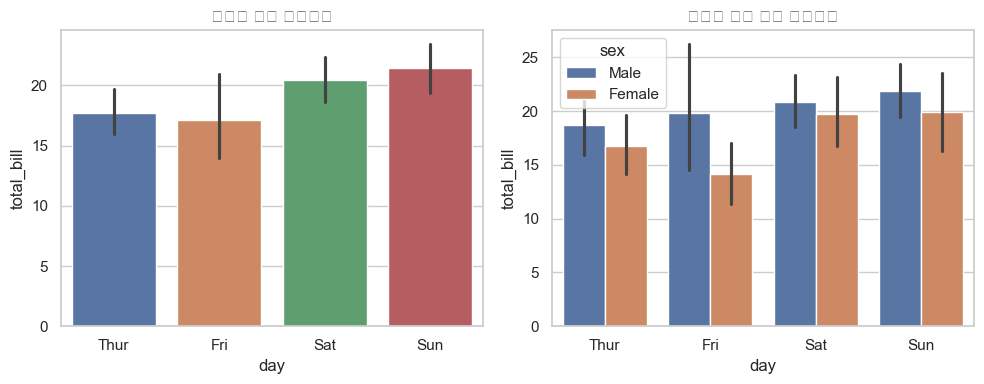

In [13]:
# [예제 1] seaborn barplot (code8_1)
import seaborn as sns
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')
print('tips 데이터 앞 3행:')
print(df.head(3))

sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})

fig, axes = plt.subplots(1, 2)

# 요일별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='day', legend=False, ax=axes[0])
axes[0].set_title('요일별 평균 청구금액')

# 요일별 성별 평균 청구금액
sns.barplot(data=df, x='day', y='total_bill', estimator='mean',
            hue='sex', ax=axes[1])
axes[1].set_title('요일별 성별 평균 청구금액')

plt.tight_layout()
plt.show()

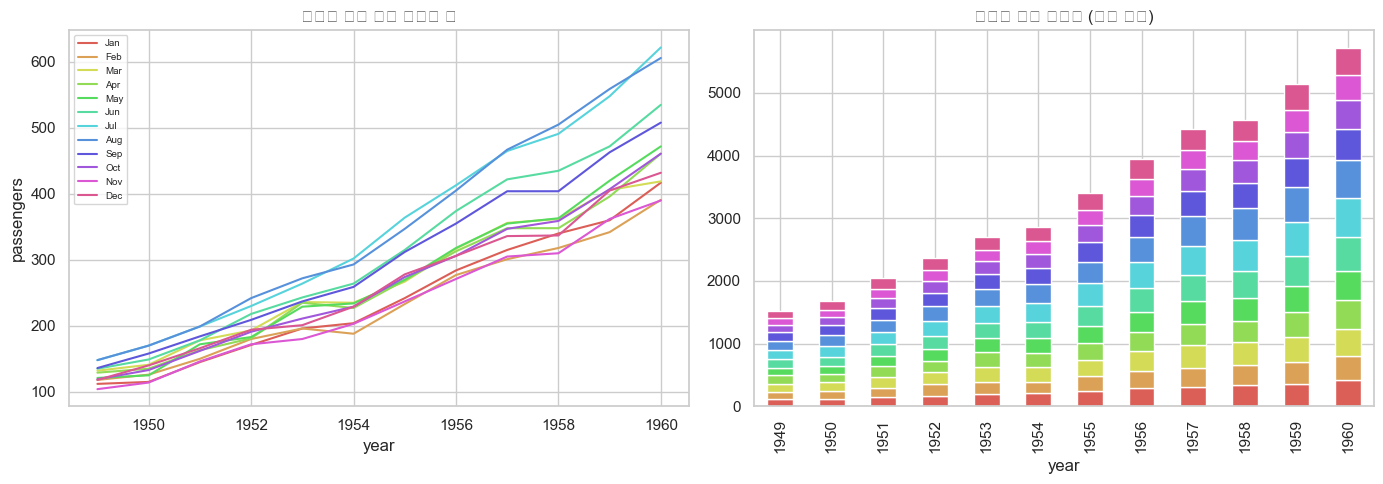

In [15]:
# [예제 2] seaborn lineplot + 누적 막대그래프 (code8_2)
import seaborn as sns
import matplotlib.pyplot as plt

flights = sns.load_dataset('flights')
sns.set_theme(style='whitegrid', rc={'figure.figsize': (10, 4)})
sns.set_palette('hls', 12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 선그래프
sns.lineplot(data=flights, x='year', y='passengers',
             hue='month', ax=axes[0])
axes[0].set_title('연도별 월별 항공 탑승객 수')
axes[0].legend(loc='upper left', fontsize=7)

# 누적 막대그래프
df2 = flights.pivot_table(index='year', columns='month',
                          values='passengers', aggfunc='mean')
df2.plot.bar(stacked=True, ax=axes[1], legend=False)
axes[1].set_title('연도별 누적 탑승객 (월별 색상)')

plt.tight_layout()
plt.show()